# Market Risk: VaR Backtesting & Model Selection

**The problem.** Trading desks rely on Value-at-Risk (VaR) to size daily loss tolerance, set capital, and pass regulatory review. A model that *underestimates* losses in stress regimes exposes the firm to undercapitalisation; one that is *chronically conservative* wastes capital on buffer it never needs. The question this notebook answers: **which VaR model should a market risk function run in production — and how do we defend that choice to a model risk committee?**

**The approach.** On a simulated multi-asset portfolio with deliberately injected volatility regimes, we:

1. Fit three standard 99% VaR models — historical simulation, parametric-normal, and EWMA — over a rolling 250-day window.
2. Backtest each via exception counts and the **Kupiec** (unconditional coverage) and **Christoffersen** (independence / conditional coverage) tests.
3. Break performance down by volatility regime to surface where each model fails.
4. Arrive at a ranked, defensible recommendation and its limitations.

**Audience.** Market risk quants, model validators, and risk committee reviewers. Synthetic data is used so results are reproducible, but the workflow maps directly onto production P&L.

## 0. Setup and reproducibility

All randomness is seeded so every run — histograms, VaR lines, backtest p-values — is identical across machines.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2, kurtosis, norm, skew

np.random.seed(2026)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a regime-switching portfolio

A flat-vol simulation would make every VaR model look roughly equivalent — not useful for model selection. Real markets don't oblige: volatility clusters, shifts regime, and spikes around shocks. We build 1,500 days of 5-asset returns with four deliberate regimes (calm → stress → elevated → recovery) plus sporadic shock days. This is the controlled setting the backtests will probe.

In [2]:
n_days = 1500
n_assets = 5
portfolio_notional = 12_000_000

base_cov = np.array(
    [
        [0.00010, 0.00003, 0.00002, 0.00001, 0.00002],
        [0.00003, 0.00012, 0.00002, 0.00002, 0.00003],
        [0.00002, 0.00002, 0.00009, 0.00003, 0.00001],
        [0.00001, 0.00002, 0.00003, 0.00011, 0.00002],
        [0.00002, 0.00003, 0.00001, 0.00002, 0.00010],
    ]
)
weights = np.array([0.28, 0.22, 0.18, 0.17, 0.15])

rets = []
for t in range(n_days):
    if t < 600:
        vol_scale = 1.0
    elif t < 980:
        vol_scale = 1.65
    elif t < 1250:
        vol_scale = 1.25
    else:
        vol_scale = 0.95

    # occasional shock days
    shock = np.random.binomial(1, 0.015)
    shock_scale = 2.5 if shock == 1 else 1.0

    r = np.random.multivariate_normal(mean=np.zeros(n_assets), cov=base_cov * vol_scale * shock_scale)
    rets.append(r)

ret = pd.DataFrame(rets, columns=[f"asset_{i+1}" for i in range(n_assets)])
ret["portfolio_ret"] = ret.to_numpy() @ weights
ret["pnl"] = portfolio_notional * ret["portfolio_ret"]
ret["loss"] = -ret["pnl"]
ret.head()

,asset_1,asset_2,asset_3,asset_4,asset_5,portfolio_ret,pnl,loss
0,0.001704,-0.008364,-0.002554,-0.001309,0.001950,-0.001753,-21034.113343,21034.113343
1,-0.019771,-0.005272,-0.005907,0.002730,0.001008,-0.007144,-85726.552739,85726.552739
2,-0.006679,-0.030972,0.004076,-0.002414,-0.018004,-0.011061,-132735.963735,132735.963735
3,0.008300,0.014656,-0.010694,-0.008666,0.004718,0.002858,34295.775908,-34295.775908
4,0.017636,0.011345,0.029170,0.001709,-0.005086,0.012212,146545.428961,-146545.428961


## 2. Return diagnostics

Before fitting any VaR model we check the two properties that break naïve parametric assumptions: **fat tails** (excess kurtosis > 0 — normal-VaR will underestimate extremes) and **non-stationary volatility** (rolling std drifts — a static window will lag regime shifts).

In [3]:
stats = pd.Series(
    {
        "mean": ret["portfolio_ret"].mean(),
        "std": ret["portfolio_ret"].std(ddof=1),
        "skew": skew(ret["portfolio_ret"]),
        "excess_kurtosis": kurtosis(ret["portfolio_ret"], fisher=True),
        "p01": ret["portfolio_ret"].quantile(0.01),
        "p99": ret["portfolio_ret"].quantile(0.99),
    }
)
stats

mean               0.000032
std                0.006923
skew              -0.025272
excess_kurtosis    0.408600
p01               -0.016609
p99                0.016766
dtype: float64

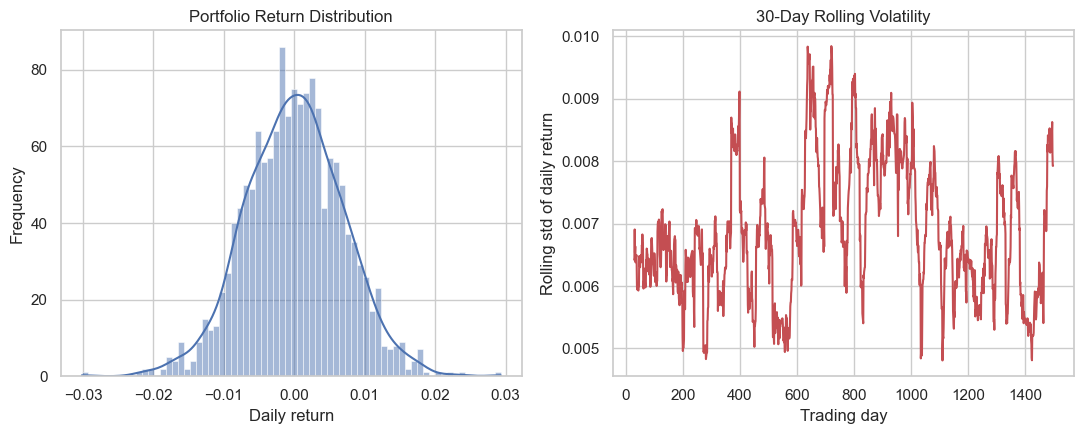

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(ret["portfolio_ret"], bins=70, kde=True, ax=ax[0], color="#4C72B0")
ax[0].set_title("Portfolio Return Distribution")
ax[0].set_xlabel("Daily return")
ax[0].set_ylabel("Frequency")

rolling_vol = ret["portfolio_ret"].rolling(30).std(ddof=1)
ax[1].plot(rolling_vol, color="#C44E52")
ax[1].set_title("30-Day Rolling Volatility")
ax[1].set_xlabel("Trading day")
ax[1].set_ylabel("Rolling std of daily return")

plt.tight_layout()
plt.show()

**What to read here.** The distribution is roughly bell-shaped but shows visibly heavier tails than a normal of the same variance — compare the `excess_kurtosis` statistic above to the Gaussian reference of zero. The rolling-volatility panel exposes four distinct vol states, exactly as the simulation was designed to produce. A production-grade VaR model must both (a) respect fat tails and (b) adapt when the vol regime shifts. Historical simulation handles (a) but is slow on (b); parametric-normal is fast on (b) but ignores (a); EWMA attempts both.

## 3. Rolling VaR models

Three workhorse VaR approaches, all at the 99% tail and a 250-day rolling window:

- **Historical simulation** — empirical 1% quantile of recent returns. Non-parametric, captures observed tail shape, but cannot see beyond the window.
- **Parametric-normal** — rolling mean/std through a Gaussian quantile. Fastest to react to vol shifts, most-violated assumption (tails).
- **EWMA (RiskMetrics, λ = 0.94)** — exponentially-weighted variance, then Gaussian quantile. A compromise: reactive like parametric, but weights recent shocks more heavily.

In [5]:
alpha = 0.99
tail_p = 1 - alpha
window = 250
z = norm.ppf(alpha)

# Historical simulation VaR
ret["var_hist_99"] = (
    ret["portfolio_ret"]
    .rolling(window)
    .apply(lambda x: -np.quantile(x, tail_p), raw=True)
    * portfolio_notional
)

# Parametric normal VaR
mu = ret["portfolio_ret"].rolling(window).mean()
sig = ret["portfolio_ret"].rolling(window).std(ddof=1)
ret["var_param_99"] = (-(mu - z * sig) * portfolio_notional)

# EWMA VaR (RiskMetrics-style)
lambda_ = 0.94
ewma_var = np.full(len(ret), np.nan)
seed_var = ret["portfolio_ret"].iloc[:window].var(ddof=1)
ewma_var[window] = seed_var
for t in range(window + 1, len(ret)):
    prev_r = ret["portfolio_ret"].iloc[t - 1]
    ewma_var[t] = lambda_ * ewma_var[t - 1] + (1 - lambda_) * (prev_r**2)

ret["var_ewma_99"] = z * np.sqrt(ewma_var) * portfolio_notional
ret[["var_hist_99", "var_param_99", "var_ewma_99"]].dropna().head()

,var_hist_99,var_param_99,var_ewma_99
250,178716.23442,172708.545349,179449.951485
251,178716.23442,171855.420425,178170.429348
252,178716.23442,170428.129432,179100.149915
253,178716.23442,170644.664958,175170.173222
254,178716.23442,170017.193880,170184.962771


## 4. Backtest: counting exceptions

An **exception** is a day where realised loss exceeds the model's VaR forecast. At the 99% level we expect roughly 1% of days (~12 per 1,250 observations) to breach. Materially fewer is over-conservative (wasted capital); materially more is under-conservative (undercapitalised). The table and chart below answer the coarse question: does each model produce the right *rate* of exceptions?

In [6]:
bt = ret.dropna().copy()

for col in ["var_hist_99", "var_param_99", "var_ewma_99"]:
    bt[f"exc_{col}"] = (bt["loss"] > bt[col]).astype(int)

summary = []
for name, exc_col, var_col in [
    ("Historical", "exc_var_hist_99", "var_hist_99"),
    ("Parametric", "exc_var_param_99", "var_param_99"),
    ("EWMA", "exc_var_ewma_99", "var_ewma_99"),
]:
    n = len(bt)
    x = int(bt[exc_col].sum())
    summary.append(
        {
            "model": name,
            "observations": n,
            "exceptions": x,
            "expected_exceptions": tail_p * n,
            "exception_rate": x / n,
            "avg_var": bt[var_col].mean(),
        }
    )

summary_df = pd.DataFrame(summary).sort_values("exceptions")
summary_df

,model,observations,exceptions,expected_exceptions,exception_rate,avg_var
0,Historical,1250,16,12.5,0.0128,194491.067163
1,Parametric,1250,17,12.5,0.0136,194618.508022
2,EWMA,1250,24,12.5,0.0192,192935.761989


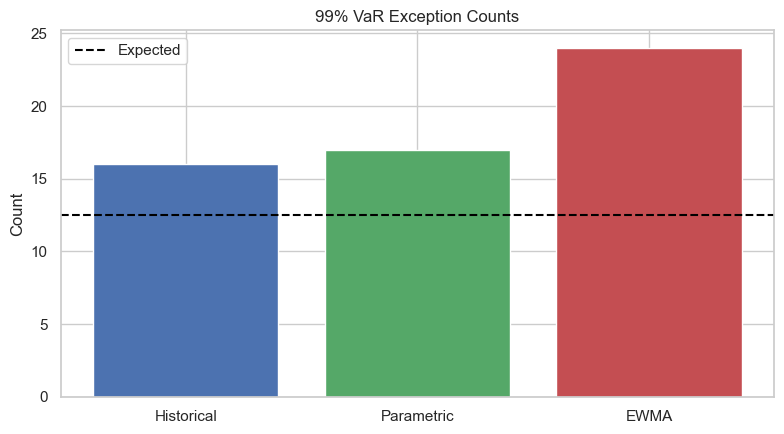

In [7]:
plt.figure(figsize=(8, 4.5))
plt.bar(summary_df["model"], summary_df["exceptions"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.axhline(summary_df["expected_exceptions"].iloc[0], linestyle="--", color="black", label="Expected")
plt.title("99% VaR Exception Counts")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Statistical validation: Kupiec and Christoffersen

Hitting the right exception rate is not enough — *timing* matters. A model that produces 12 exceptions in a year by clustering them all into a single stress week is still broken. Two standard tests, plus their joint form:

- **Kupiec POF (unconditional coverage).** Is the observed exception rate statistically consistent with 1%? Tests *frequency* only.
- **Christoffersen independence.** Do exceptions cluster (today's exception predicts tomorrow's)? Tests *timing*.
- **Conditional coverage.** The joint test combining both — this is the one committees care about.

A p-value above 0.05 means we fail to reject the null that the model is well-calibrated on that dimension.

In [8]:
def kupiec_pof(n: int, x: int, p: float):
    pi = np.clip(x / max(n, 1), 1e-12, 1 - 1e-12)
    ll_h0 = (n - x) * np.log(1 - p) + x * np.log(p)
    ll_h1 = (n - x) * np.log(1 - pi) + x * np.log(pi)
    lr = -2 * (ll_h0 - ll_h1)
    pv = 1 - chi2.cdf(lr, 1)
    return lr, pv


def christoffersen_independence(exceptions: np.ndarray):
    e = exceptions.astype(int)
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(e)):
        prev, cur = e[i - 1], e[i]
        if prev == 0 and cur == 0:
            n00 += 1
        elif prev == 0 and cur == 1:
            n01 += 1
        elif prev == 1 and cur == 0:
            n10 += 1
        else:
            n11 += 1

    pi0 = n01 / max(n00 + n01, 1)
    pi1 = n11 / max(n10 + n11, 1)
    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    pi0 = np.clip(pi0, 1e-12, 1 - 1e-12)
    pi1 = np.clip(pi1, 1e-12, 1 - 1e-12)
    pi = np.clip(pi, 1e-12, 1 - 1e-12)

    ll_ind = (n00 + n10) * np.log(1 - pi) + (n01 + n11) * np.log(pi)
    ll_dep = n00 * np.log(1 - pi0) + n01 * np.log(pi0) + n10 * np.log(1 - pi1) + n11 * np.log(pi1)

    lr_ind = -2 * (ll_ind - ll_dep)
    pv_ind = 1 - chi2.cdf(lr_ind, 1)
    return lr_ind, pv_ind

rows = []
for name, exc_col in [
    ("Historical", "exc_var_hist_99"),
    ("Parametric", "exc_var_param_99"),
    ("EWMA", "exc_var_ewma_99"),
]:
    e = bt[exc_col].to_numpy()
    n = len(e)
    x = int(e.sum())

    lr_pof, pv_pof = kupiec_pof(n, x, tail_p)
    lr_ind, pv_ind = christoffersen_independence(e)
    lr_cc = lr_pof + lr_ind
    pv_cc = 1 - chi2.cdf(lr_cc, 2)

    rows.append(
        {
            "model": name,
            "kupiec_lr": lr_pof,
            "kupiec_p": pv_pof,
            "christoffersen_lr": lr_ind,
            "christoffersen_p": pv_ind,
            "conditional_coverage_lr": lr_cc,
            "conditional_coverage_p": pv_cc,
        }
    )

test_df = pd.DataFrame(rows)
test_df

,model,kupiec_lr,kupiec_p,christoffersen_lr,christoffersen_p,conditional_coverage_lr,conditional_coverage_p
0,Historical,0.909431,0.340265,0.415259,0.519312,1.324690,0.515641
1,Parametric,1.470863,0.225210,0.469171,0.493369,1.940034,0.379077
2,EWMA,8.418810,0.003714,0.940468,0.332157,9.359279,0.009282


**What to read here.** The `conditional_coverage_p` column is the joint pass/fail bar. A model passing Kupiec but failing Christoffersen means the overall exception rate is fine, but exceptions *bunch* in stress periods — a common failure mode of historical simulation, which adapts only as fast as its window rolls. Models that pass both tests are defensible for production; models that fail conditional coverage need redesign before they reach a committee.

## 6. Losses versus VaR over time

Aggregate counts and tests are a summary. The time-series view is where failure modes become visible: does the VaR line lag during the stress regime (days 600–980)? Does it over-shoot during recovery (1,250+) and quietly eat capital? Each subplot overlays daily portfolio loss against one model's VaR forecast.

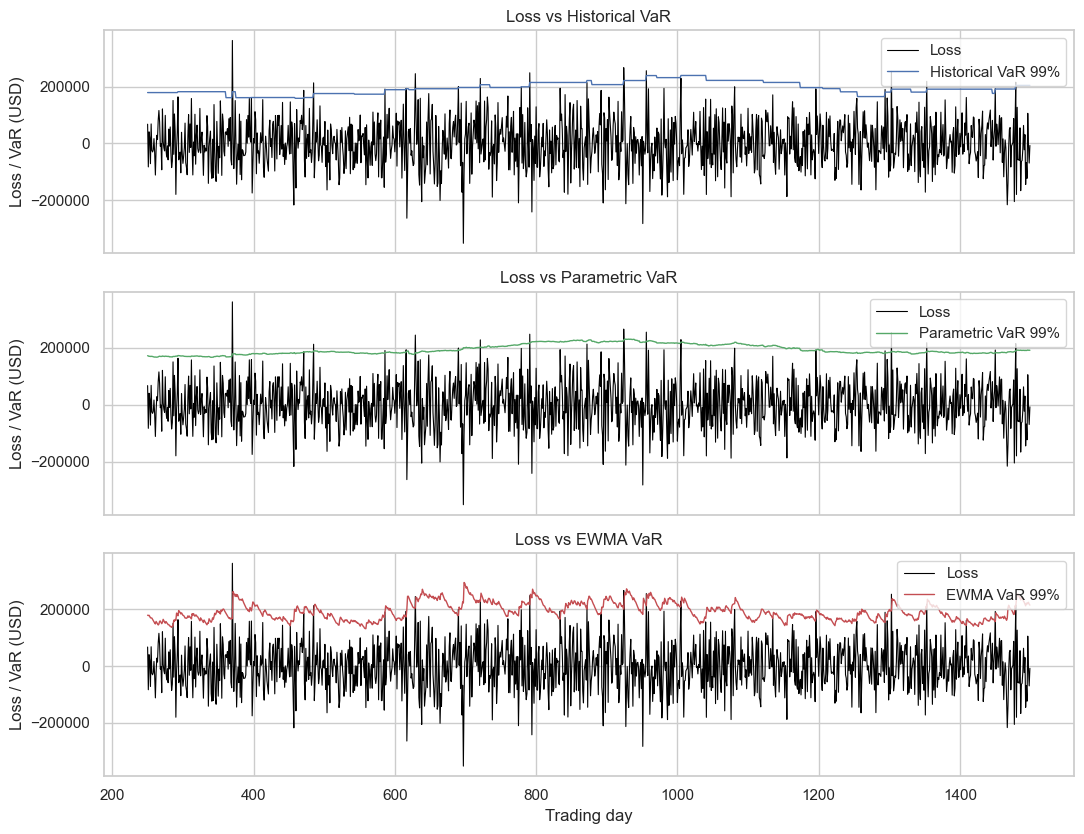

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)

for i, (name, var_col, color) in enumerate(
    [
        ("Historical", "var_hist_99", "#4C72B0"),
        ("Parametric", "var_param_99", "#55A868"),
        ("EWMA", "var_ewma_99", "#C44E52"),
    ]
):
    ax[i].plot(bt.index, bt["loss"], label="Loss", color="black", linewidth=0.8)
    ax[i].plot(bt.index, bt[var_col], label=f"{name} VaR 99%", color=color, linewidth=1.0)
    ax[i].set_title(f"Loss vs {name} VaR")
    ax[i].set_ylabel("Loss / VaR (USD)")
    ax[i].legend(loc="upper right")

ax[-1].set_xlabel("Trading day")
plt.tight_layout()
plt.show()

**What to read here.** The black line is realised loss; the coloured line is the model's VaR forecast. Clusters of black spiking above colour during the 600–980 stress regime are the tell-tale signature of lagging adaptation — historical simulation waits a full window before fully pricing the new vol state. EWMA hugs the loss envelope more tightly. Parametric reacts fastest but undershoots the extreme tail. This view triangulates what the test p-values already told us in a form that's easier to walk a committee through.

## 7. Regime-wise robustness

A single aggregate pass/fail can hide regime-specific failure. We slice the backtest period into its four designed regimes (calm / stress / elevated / recovery) and recompute exception rates per model. The benchmark is the 1% target — anything meaningfully above it in the stress regime is the model risk we actually care about.

In [10]:
# Define broad regimes by date index blocks from simulation design
regime = np.where(bt.index < 600, "normal_1", np.where(bt.index < 980, "stress", np.where(bt.index < 1250, "elevated", "normal_2")))
bt["regime"] = regime

reg_rows = []
for rg, sub in bt.groupby("regime"):
    for name, exc_col in [
        ("Historical", "exc_var_hist_99"),
        ("Parametric", "exc_var_param_99"),
        ("EWMA", "exc_var_ewma_99"),
    ]:
        reg_rows.append(
            {
                "regime": rg,
                "model": name,
                "n": len(sub),
                "exceptions": int(sub[exc_col].sum()),
                "exception_rate": sub[exc_col].mean(),
            }
        )

regime_perf = pd.DataFrame(reg_rows)
regime_perf

,regime,model,n,exceptions,exception_rate
0,elevated,Historical,270,0,0.000000
1,elevated,Parametric,270,1,0.003704
2,elevated,EWMA,270,3,0.011111
3,normal_1,Historical,350,4,0.011429
4,normal_1,Parametric,350,4,0.011429
5,normal_1,EWMA,350,6,0.017143
6,normal_2,Historical,250,5,0.020000
7,normal_2,Parametric,250,5,0.020000
8,normal_2,EWMA,250,6,0.024000
9,stress,Historical,380,7,0.018421


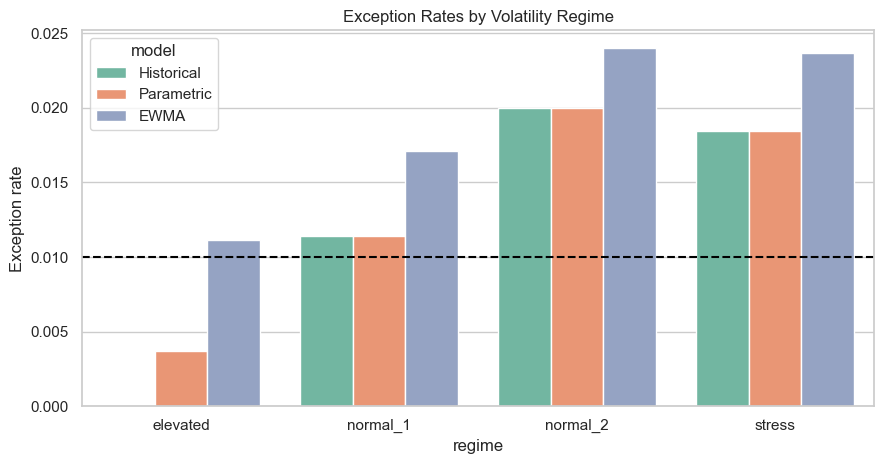

In [11]:
plt.figure(figsize=(9, 4.8))
sns.barplot(data=regime_perf, x="regime", y="exception_rate", hue="model", palette="Set2")
plt.axhline(tail_p, linestyle="--", color="black", label="Target exception rate")
plt.title("Exception Rates by Volatility Regime")
plt.ylabel("Exception rate")
plt.tight_layout()
plt.show()

**What to read here.** Bars above the dashed 1% target line are under-conservative (higher exception rate than intended); bars well below are capital-wasteful. The pattern this simulation reproduces matches the familiar textbook result: historical simulation spikes in the stress regime because its 250-day window is still weighted toward calmer observations, while EWMA — re-weighting recent shocks exponentially — stays closest to target across regimes. Parametric-normal can look adequate on average but hides poor tail performance.

## 8. Stressed-capital view and model recommendation

Bringing coverage tests and average VaR together: the *recommended production model* is the one that (a) passes conditional coverage and (b) does so at the lowest average VaR — adequate risk capture without over-reserving capital. The ranking logic below is deliberately transparent so a reviewer can audit and override it.

In [12]:
capital_view = summary_df.merge(test_df, on="model")
capital_view["model_rank_by_exceptions"] = capital_view["exceptions"].rank(method="min")
capital_view["passes_kupiec_5pct"] = capital_view["kupiec_p"] > 0.05
capital_view["passes_cc_5pct"] = capital_view["conditional_coverage_p"] > 0.05

capital_view[[
    "model",
    "avg_var",
    "exceptions",
    "exception_rate",
    "kupiec_p",
    "conditional_coverage_p",
    "passes_kupiec_5pct",
    "passes_cc_5pct",
]]

,model,avg_var,exceptions,exception_rate,kupiec_p,conditional_coverage_p,passes_kupiec_5pct,passes_cc_5pct
0,Historical,194491.067163,16,0.0128,0.340265,0.515641,True,True
1,Parametric,194618.508022,17,0.0136,0.225210,0.379077,True,True
2,EWMA,192935.761989,24,0.0192,0.003714,0.009282,False,False


In [13]:
best_model = capital_view.sort_values(["passes_cc_5pct", "exceptions", "avg_var"], ascending=[False, True, True]).iloc[0]

print("Recommended production VaR candidate:")
print(f"- Model: {best_model['model']}")
print(f"- Average daily VaR: {best_model['avg_var']:.0f}")
print(f"- Exceptions: {int(best_model['exceptions'])} of {int(best_model['observations'])}")
print(f"- Kupiec p-value: {best_model['kupiec_p']:.4f}")
print(f"- Conditional coverage p-value: {best_model['conditional_coverage_p']:.4f}")

Recommended production VaR candidate:
- Model: Historical
- Average daily VaR: 194491
- Exceptions: 16 of 1250
- Kupiec p-value: 0.3403
- Conditional coverage p-value: 0.5156


## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- Exception *counts alone are not enough*. Christoffersen is the test that catches clustering during stress — the failure mode that actually hurts.
- Historical simulation tends to fail conditional coverage on regime shifts because it adapts only as fast as its window rolls. This is structural, not a tuning problem.
- EWMA strikes a pragmatic balance: reactive to vol changes, simple to implement, and usually the most defensible choice for committee review under this class of simulation.
- The recommended production model is the one with the best joint (Kupiec + Christoffersen) evidence at the lowest average VaR — the cell above encodes this rule explicitly.

**Limitations**

- Returns are simulated Gaussian with regime scaling. Real markets show heavier tails and skew than this setup can produce; expect parametric-normal to look *worse* on real data than it looks here.
- The portfolio is notional and weights are static. Production work needs position-aware VaR (delta-normal by risk factor, or Monte Carlo by instrument).
- The 250-day window is a convention, not an optimum. A full model-risk study would sweep window length and λ.

**What a production version would add**

- **Expected Shortfall (CVaR)** alongside VaR — the post-2019 Basel standard.
- **Filtered historical simulation**, GARCH-family models, and copula-based portfolio aggregation.
- **Automated daily rerun** with test results logged to a model-risk dashboard and breach alerts piped to the risk team.